Big Mart Sales Data Analysis

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#load dataset
df = pd.read_csv('./data/bigmart_train.csv')
df.shape

(8523, 12)

In [3]:
# check the types of colums
df.dtypes

Item_Identifier                  str
Item_Weight                  float64
Item_Fat_Content                 str
Item_Visibility              float64
Item_Type                        str
Item_MRP                     float64
Outlet_Identifier                str
Outlet_Establishment_Year      int64
Outlet_Size                      str
Outlet_Location_Type             str
Outlet_Type                      str
Item_Outlet_Sales            float64
dtype: object

In [4]:
df.head(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


Data Cleaning

In [5]:
'''
Categorical data: Item_Type,Outlet_Type,Outlet_Size,item_fat_content,Outletsize
Numerical data: Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales
'''

'\nCategorical data: Item_Type,Outlet_Type,Outlet_Size,item_fat_content,Outletsize\nNumerical data: Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales\n'

In [6]:
df['Item_Weight'].isna().sum()

np.int64(1463)

In [7]:
mean_weight = df['Item_Weight'].mean()
df['Item_Weight'] = df['Item_Weight'].fillna(mean_weight)


In [8]:
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [30]:
# Replace maaping of old names with new ones 
clean_map = {
    'LF':'Low Fat',
    'low fat':'Low Fat',
    'reg':'Regular'
}
# Apply transfromation 
df['Item_Fat_Content']=df['Item_Fat_Content'].replace(clean_map)
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

In [11]:
df['Outlet_Size'].isna().sum()

np.int64(2410)

In [12]:
'''
If you treat it like normal numeric:

Mean of years → meaningless 
Correlation with sales → misleading 
Model/analysis won’t understand “time effect” properly 
'''

# created a new feature called Outlet Age eg outlet age = current_year - est_year

from datetime import datetime
current_year = datetime.now().year

df['Outlet_year'] = current_year-df['Outlet_Establishment_Year']
df.isna().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
Outlet_year                     0
dtype: int64

In [13]:
mode_size = df['Outlet_Size'].mode()[0]
df['Outlet_Size'] = df['Outlet_Size'].fillna(mode_size) 
# .mode() → returns list-like output [0] → extracts actual value (e.g., "Medium")

In [14]:
df.isna().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
Outlet_year                  0
dtype: int64

In [15]:
df.head(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_year
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,27
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,17
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,27
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800,28
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,39


(array([3.280e+03, 2.448e+03, 1.527e+03, 7.290e+02, 3.590e+02, 1.240e+02,
        3.600e+01, 1.600e+01, 2.000e+00, 2.000e+00]),
 array([   33.29   ,  1338.65748,  2644.02496,  3949.39244,  5254.75992,
         6560.1274 ,  7865.49488,  9170.86236, 10476.22984, 11781.59732,
        13086.9648 ]),
 <BarContainer object of 10 artists>)

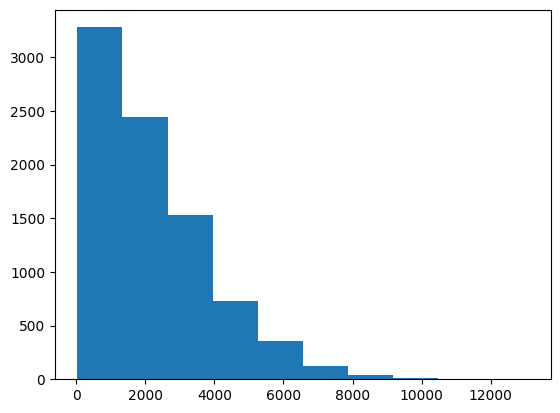

In [16]:
plt.hist(df['Item_Outlet_Sales'])


In [16]:
df['Item_Outlet_Sales'].describe()

count     8523.000000
mean      2181.288914
std       1706.499616
min         33.290000
25%        834.247400
50%       1794.331000
75%       3101.296400
max      13086.964800
Name: Item_Outlet_Sales, dtype: float64

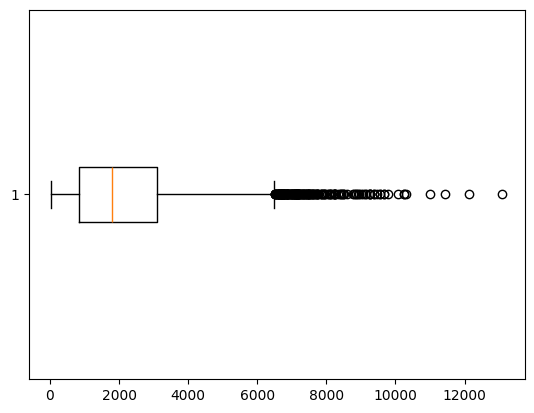

In [17]:
plt.boxplot(df['Item_Outlet_Sales'],vert=False)
plt.show()

In [18]:
# SUMMARY ANALYSIS OF ITEM_OUTLET_SALES
# 1. Distribution Shape: The data is heavily RIGHT-SKEWED (Positively Skewed).
#    - This indicates that most products/outlets generate lower to mid-range sales.
#    - A small number of observations generate exceptionally high revenue (the 'long tail').

# 2. Key Sales Thresholds:
#    - Low Sales (Bottom 25%): Items making less than $834.
#    - Typical Sales (Median): $1,794 is the "middle" value, more representative than the mean.
#    - High Sales (Top 25%): Items making more than $3,101.

# 3. The "Outlier" Effect:
#    - The gap between the 75th percentile ($3,101) and the Maximum ($13,086) is massive.
#    - These 'Outliers' (the circles in the boxplot) represent the 'Super-Performers'.
#    - Business Insight: Revenue is likely driven by a few high-performing outlets 
#      or premium product categories, while the majority of the business 
#      operates in the $800 - $3,000 range.

# 4. Data Preparation Note:
#    - Because of the high skewness and outliers, this column may need 
#      Log Transformation before training Machine Learning models to 
#      ensure the extreme values don't bias the predictions.

(array([ 923.,  573., 1053., 1248.,  804., 1098., 1200.,  480.,  557.,
         587.]),
 array([ 31.29   ,  54.84984,  78.40968, 101.96952, 125.52936, 149.0892 ,
        172.64904, 196.20888, 219.76872, 243.32856, 266.8884 ]),
 <BarContainer object of 10 artists>)

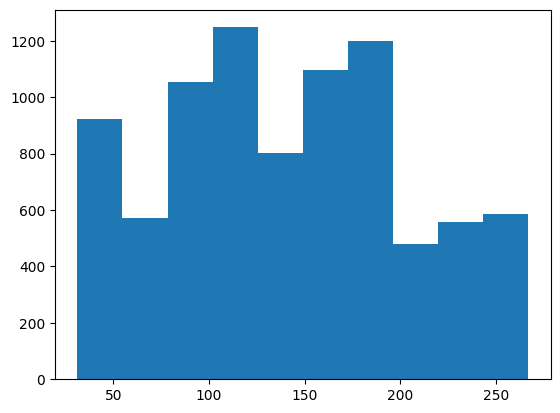

In [18]:
# Item MRP -> It has direct chances that it affects Sales 

plt.hist(df['Item_MRP'])

In [19]:
df['Item_MRP'].mean()
df['Item_MRP'].median()
df['Item_MRP'].skew()

np.float64(0.1272022683110526)

**
Item MRP distribution is approximately symmetric with a very mild right skew (skew = 0.127), so mean and median are nearly equal, with mean slightly higher.


In [20]:
df['Item_MRP'].describe()

count    8523.000000
mean      140.992782
std        62.275067
min        31.290000
25%        93.826500
50%       143.012800
75%       185.643700
max       266.888400
Name: Item_MRP, dtype: float64

In [21]:
# Item visbility 
# How is Item_Visibility distributed?
# Histogram 
df['Item_Visibility'].describe()

count    8523.000000
mean        0.066132
std         0.051598
min         0.000000
25%         0.026989
50%         0.053931
75%         0.094585
max         0.328391
Name: Item_Visibility, dtype: float64

(array([2639., 2329., 1563.,  979.,  593.,  279.,   60.,   35.,   29.,
          17.]),
 array([0.        , 0.03283909, 0.06567819, 0.09851728, 0.13135638,
        0.16419547, 0.19703457, 0.22987366, 0.26271276, 0.29555185,
        0.32839095]),
 <BarContainer object of 10 artists>)

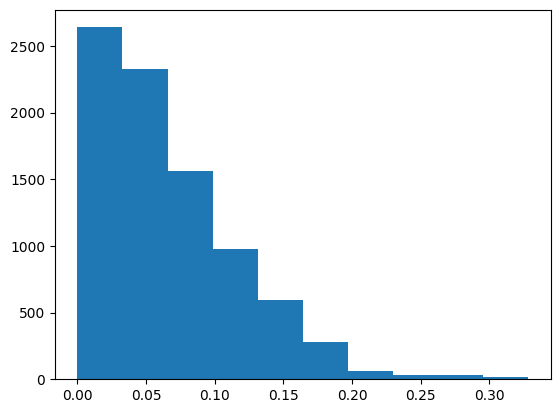

In [22]:
plt.hist(df['Item_Visibility'])

{'whiskers': [<matplotlib.lines.Line2D at 0x2ca2374b500>,
 'caps': [<matplotlib.lines.Line2D at 0x2ca2374bb00>,
 'boxes': [<matplotlib.lines.Line2D at 0x2ca2374b2c0>],
 'medians': [<matplotlib.lines.Line2D at 0x2ca2374bf50>],
 'fliers': [<matplotlib.lines.Line2D at 0x2ca23784290>],
 'means': []}

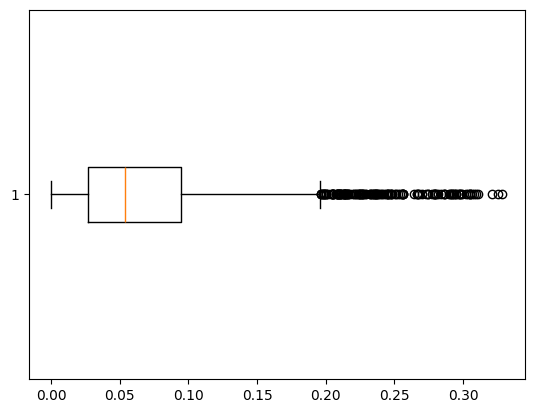

In [25]:
# Right skewness is col low value are higher in rnage 0-> 0.1
# Box plot -> helps us to find Outliers and spreadness of data 
plt.boxplot(df['Item_Visibility'],vert=False)


In [ ]:
'''
The Item_Visibility distribution is right-skewed, with most values concentrated at lower levels (median around 0.05). The majority of items have visibility between 0.02 and 0.10, indicating generally low product exposure in stores.

A significant number of high-value outliers (above 0.20) suggest that only a small subset of items receive high visibility.

Additionally, the presence of very low or zero visibility values may indicate potential data inconsistencies, as completely invisible items are unlikely in real-world retail settings.
'''

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'Fruits and Vegetables'),
  Text(1, 0, 'Snack Foods'),
  Text(2, 0, 'Household'),
  Text(3, 0, 'Frozen Foods'),
  Text(4, 0, 'Dairy'),
  Text(5, 0, 'Canned'),
  Text(6, 0, 'Baking Goods'),
  Text(7, 0, 'Health and Hygiene'),
  Text(8, 0, 'Soft Drinks'),
  Text(9, 0, 'Meat'),
  Text(10, 0, 'Breads'),
  Text(11, 0, 'Hard Drinks'),
  Text(12, 0, 'Others'),
  Text(13, 0, 'Starchy Foods'),
  Text(14, 0, 'Breakfast'),
  Text(15, 0, 'Seafood')])

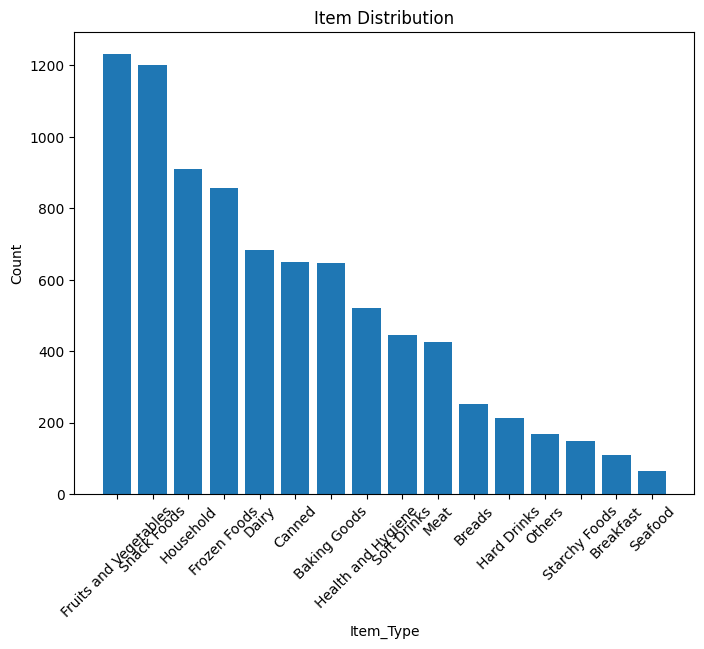

In [ ]:
# Item_ Type 
# Bar chart needs:
# X → unique categories -> so .index is used 
# Y → their counts
# Step 1: Count each category

item_counts = df['Item_Type'].value_counts()

# Step 2: Create bar chart
plt.figure(figsize=(8,6))
plt.bar(item_counts.index,item_counts.values)
plt.title('Item Distribution')
plt.xlabel("Item_Type")
plt.ylabel('Count')
plt.xticks(rotation=45)

([0, 1, 2, 3],
 [Text(0, 0, 'Supermarket Type1'),
  Text(1, 0, 'Grocery Store'),
  Text(2, 0, 'Supermarket Type3'),
  Text(3, 0, 'Supermarket Type2')])

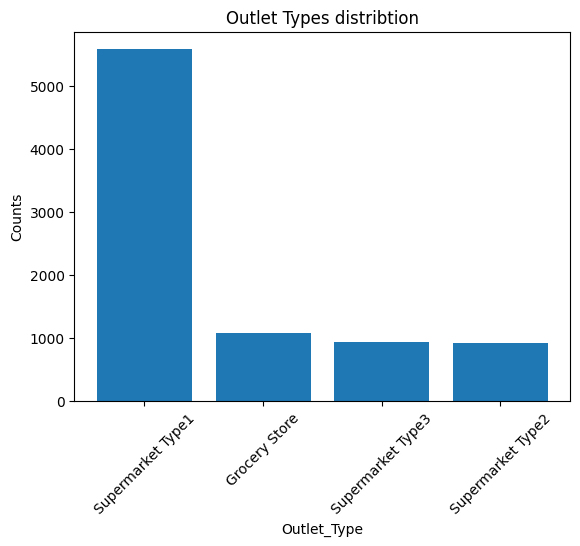

In [25]:
type_count = df['Outlet_Type'].value_counts()
plt.bar(type_count.index,type_count.values)
plt.title('Outlet Types distribtion')
plt.xlabel('Outlet_Type')
plt.ylabel('Counts')
plt.xticks(rotation=45)


Text(0, 0.5, 'Count')

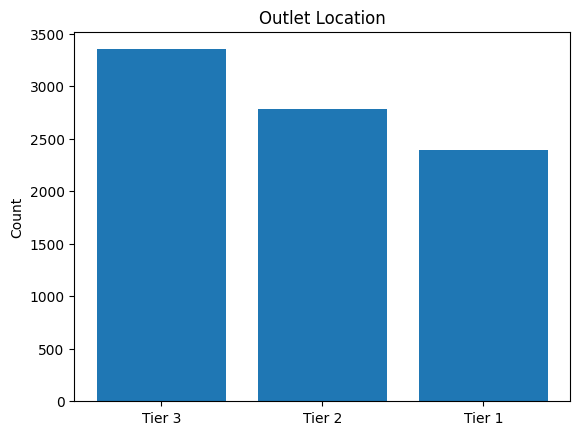

In [27]:
# Outlet location tyoe 
location_count = df['Outlet_Location_Type'].value_counts()
plt.bar(location_count.index,location_count.values)
plt.title('Outlet Location')
plt.ylabel('Count')

In [ ]:
df['Item_Fat_Content'].value_counts()
df

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

Text(0, 0.5, 'Sales')

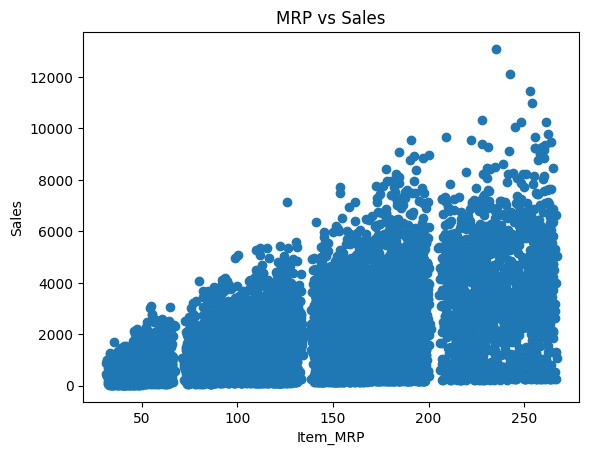

In [34]:
# Bivariate Analysis 
# What factors did affect Item_outlet_sales 
# For this we take one col and compare with sales 
plt.scatter(df['Item_MRP'],df['Item_Outlet_Sales'])
plt.title('MRP vs Sales')
plt.xlabel('Item_MRP')
plt.ylabel('Sales')

In [36]:
'''
Since the value increases as x increases so here is a positive relationship between MRP and sales
The scatter plot shows a positive relationship between Item MRP and Item Outlet Sales, indicating that higher-priced items tend to generate higher sales.

However, the relationship is not strictly linear, as the data appears in distinct clusters, suggesting that products are grouped into specific price bands.

Additionally, higher MRP items exhibit greater variability in sales, meaning they can either perform very well or poorly.

Lower-priced items generally generate lower sales and rarely reach high revenue levels.
'''

'\nSince the value increases as x increases so here is a positive relationship between MRP and sales\nThe scatter plot shows a positive relationship between Item MRP and Item Outlet Sales, indicating that higher-priced items tend to generate higher sales.\n\nHowever, the relationship is not strictly linear, as the data appears in distinct clusters, suggesting that products are grouped into specific price bands.\n\nAdditionally, higher MRP items exhibit greater variability in sales, meaning they can either perform very well or poorly.\n\nLower-priced items generally generate lower sales and rarely reach high revenue levels.\n'

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'Dairy'),
  Text(1, 0, 'Soft Drinks'),
  Text(2, 0, 'Meat'),
  Text(3, 0, 'Fruits and Vegetables'),
  Text(4, 0, 'Household'),
  Text(5, 0, 'Baking Goods'),
  Text(6, 0, 'Snack Foods'),
  Text(7, 0, 'Frozen Foods'),
  Text(8, 0, 'Breakfast'),
  Text(9, 0, 'Health and Hygiene'),
  Text(10, 0, 'Hard Drinks'),
  Text(11, 0, 'Canned'),
  Text(12, 0, 'Breads'),
  Text(13, 0, 'Starchy Foods'),
  Text(14, 0, 'Others'),
  Text(15, 0, 'Seafood')])

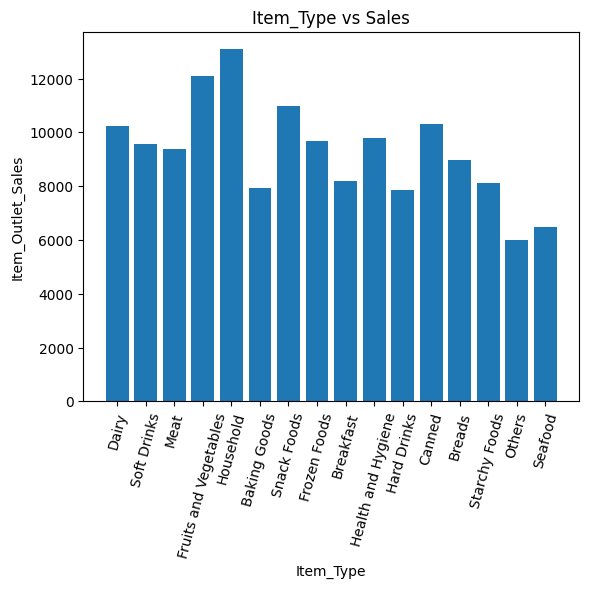

In [45]:
plt.bar(df['Item_Type'],df['Item_Outlet_Sales'])
plt.xlabel('Item_Type')
plt.ylabel('Item_Outlet_Sales')
plt.title('Item_Type vs Sales')
plt.xticks(rotation=75)

In [47]:
'''
The analysis shows that "Fruits and Vegetables" and "Households" are the top-performing item categories in terms of sales, indicating strong customer demand.

On the other hand, categories like "Seafood" and "Others" contribute the least to total sales, suggesting lower demand or limited availability.

Most categories fall within a similar sales range, indicating relatively balanced performance, but a few categories clearly outperform others.
'''

'\nThe analysis shows that "Fruits and Vegetables" and "Households" are the top-performing item categories in terms of sales, indicating strong customer demand.\n\nOn the other hand, categories like "Seafood" and "Others" contribute the least to total sales, suggesting lower demand or limited availability.\n\nMost categories fall within a similar sales range, indicating relatively balanced performance, but a few categories clearly outperform others.\n'

([0, 1, 2, 3],
 [Text(0, 0, 'Supermarket Type1'),
  Text(1, 0, 'Supermarket Type2'),
  Text(2, 0, 'Grocery Store'),
  Text(3, 0, 'Supermarket Type3')])

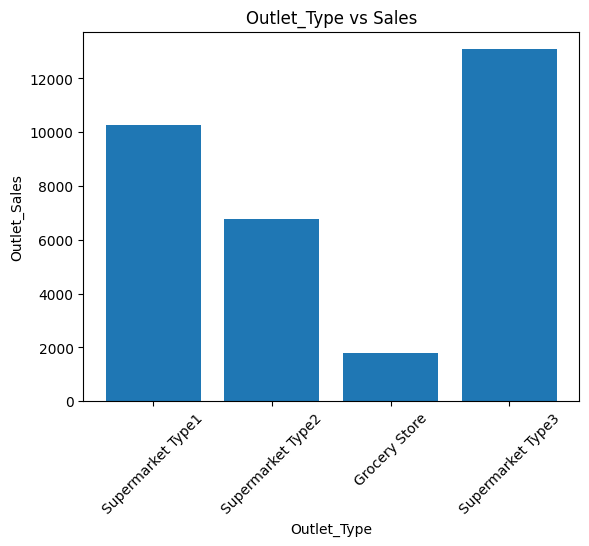

In [48]:
plt.bar(df['Outlet_Type'],df['Item_Outlet_Sales'])
plt.title('Outlet_Type vs Sales')
plt.xlabel('Outlet_Type')
plt.ylabel('Outlet_Sales')
plt.xticks(rotation=45)

In [49]:
'''The analysis shows that Supermarket Type 3 generates the highest sales among all outlet types, indicating stronger customer reach or higher product demand in these stores. In contrast, Grocery Stores contribute the lowest sales, suggesting comparatively lower customer traffic or limited product variety.'''

'The analysis shows that Supermarket Type 3 generates the highest sales among all outlet types, indicating stronger customer reach or higher product demand in these stores. In contrast, Grocery Stores contribute the lowest sales, suggesting comparatively lower customer traffic or limited product variety.'

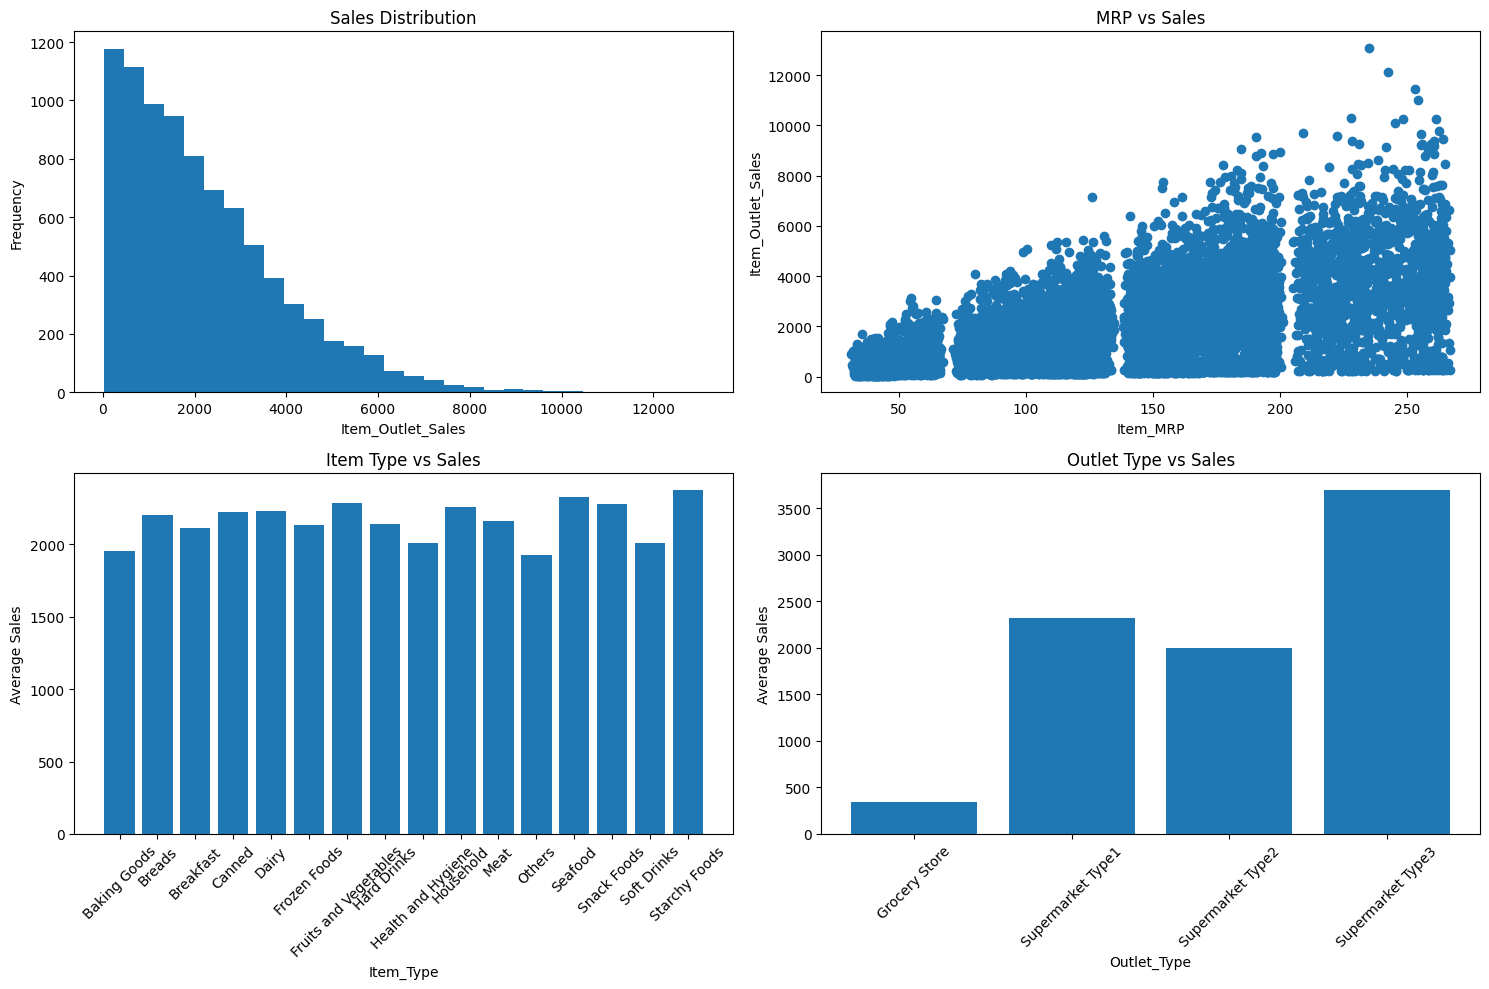

In [50]:
# Create 2x2 subplot layout
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# 1. Sales Distribution Histogram
ax[0, 0].hist(df['Item_Outlet_Sales'], bins=30)
ax[0, 0].set_title('Sales Distribution')
ax[0, 0].set_xlabel('Item_Outlet_Sales')
ax[0, 0].set_ylabel('Frequency')

# 2. MRP vs Sales Scatter Plot
ax[0, 1].scatter(df['Item_MRP'], df['Item_Outlet_Sales'])

ax[0, 1].set_title('MRP vs Sales')
ax[0, 1].set_xlabel('Item_MRP')
ax[0, 1].set_ylabel('Item_Outlet_Sales')

# 3. Item Type vs Sales
item_sales = df.groupby('Item_Type')['Item_Outlet_Sales'].mean()

ax[1, 0].bar(item_sales.index, item_sales.values)

ax[1, 0].set_title('Item Type vs Sales')
ax[1, 0].set_xlabel('Item_Type')
ax[1, 0].set_ylabel('Average Sales')

ax[1, 0].tick_params(axis='x', rotation=45)


# 4. Outlet Type vs Sales
outlet_sales = df.groupby('Outlet_Type')['Item_Outlet_Sales'].mean()
ax[1, 1].bar(outlet_sales.index, outlet_sales.values)
ax[1, 1].set_title('Outlet Type vs Sales')
ax[1, 1].set_xlabel('Outlet_Type')
ax[1, 1].set_ylabel('Average Sales')
ax[1, 1].tick_params(axis='x', rotation=45)


# Adjust layout
plt.tight_layout()

# Show dashboard
plt.show()